#  Pipeline CNN Complet — Entraînement et Comparaison de Modèles

**Steve Ataky, PhD**  
*Traitement d'images et Intelligence Artificielle*

---

## Structure attendue des données

```
data/
├── dataset1/
│   ├── classe_A/
│   │   ├── img001.jpg
│   │   ├── img002.jpg
│   │   └── ...
│   ├── classe_B/
│   │   └── ...
│   └── classe_C/
│       └── ...
├── dataset2/
│   ├── chats/
│   ├── chiens/
│   └── oiseaux/
└── ...
```

**Chaque sous-dossier = une classe.** Le nom du sous-dossier sera le label.

---

## Contenu du notebook

| Partie | Description |
|--------|-------------|
| **1** | Entraîner un CNN personnalisé sur chaque dataset |
| **2** | Extraction de features (LeNet-5, AlexNet, VGG, ResNet, GoogLeNet, MobileNet) + classifieurs ML |
| **3** | Même chose avec GridSearchCV pour optimisation |


## 📦 Installation et Imports

In [1]:
# ============================================================
# INSTALLATIONS (décommenter si nécessaire)
# ============================================================
# !pip install torch torchvision scikit-learn xgboost lightgbm matplotlib seaborn tqdm

# ============================================================
# IMPORTS GÉNÉRAUX
# ============================================================
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

# PyTorch et torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# XGBoost et LightGBM
import xgboost as xgb
import lightgbm as lgb

# Ignorer les avertissements non critiques
warnings.filterwarnings('ignore')

# Détection GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Appareil utilisé : {DEVICE}")
print(f"📦 PyTorch version : {torch.__version__}")


🖥️  Appareil utilisé : cpu
📦 PyTorch version : 2.11.0+cu130


## ⚙️ Configuration Globale

In [2]:
# ============================================================
# CONFIGURATION — MODIFIEZ ICI SELON VOS BESOINS
# ============================================================

# Chemin vers le dossier contenant les datasets
CHEMIN_DONNEES = "data"

# Taille des images (redimensionnées pour le CNN)
TAILLE_IMAGE = 224  # 224x224 est le standard pour les modèles pré-entraînés

# Paramètres d'entraînement du CNN personnalisé (Partie 1)
BATCH_SIZE = 32        # Nombre d'images par batch
EPOCHS = 20            # Nombre d'époques d'entraînement
TAUX_APPRENTISSAGE = 0.001  # Learning rate
PROPORTION_TEST = 0.2  # 20% des données pour le test

# Graine aléatoire pour la reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✅ Configuration chargée")
print(f"   📁 Chemin données : {CHEMIN_DONNEES}")
print(f"   🖼️  Taille images : {TAILLE_IMAGE}x{TAILLE_IMAGE}")
print(f"   📊 Batch size : {BATCH_SIZE}")
print(f"   🔄 Époques : {EPOCHS}")
print(f"   📈 Taux d'apprentissage : {TAUX_APPRENTISSAGE}")


✅ Configuration chargée
   📁 Chemin données : data
   🖼️  Taille images : 224x224
   📊 Batch size : 32
   🔄 Époques : 20
   📈 Taux d'apprentissage : 0.001


## 🔧 Fonctions Utilitaires

In [3]:
# ============================================================
# TRANSFORMATIONS D'IMAGES
# ============================================================

# Transformations pour l'entraînement (avec augmentation)
transform_train = transforms.Compose([
    transforms.Resize((TAILLE_IMAGE, TAILLE_IMAGE)),  # Redimensionner
    transforms.RandomHorizontalFlip(p=0.5),            # Flip horizontal aléatoire
    transforms.RandomRotation(15),                      # Rotation aléatoire ±15°
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Variation couleur
    transforms.ToTensor(),                              # Convertir en tenseur [0,1]
    transforms.Normalize(                               # Normaliser (moyenne/écart-type ImageNet)
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transformations pour le test (sans augmentation)
transform_test = transforms.Compose([
    transforms.Resize((TAILLE_IMAGE, TAILLE_IMAGE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Transformations définies")


✅ Transformations définies


In [4]:
# ============================================================
# FONCTION : CHARGER UN DATASET
# ============================================================
def charger_dataset(chemin_dataset):
    """
    Charge un dataset depuis un dossier structuré en sous-dossiers (1 par classe).
    Retourne les DataLoaders d'entraînement et de test.
    
    Paramètres:
        chemin_dataset (str): Chemin vers le dossier du dataset
    
    Retourne:
        train_loader, test_loader, classes, dataset_complet
    """
    # Charger toutes les images avec ImageFolder (détecte les sous-dossiers automatiquement)
    dataset_complet = datasets.ImageFolder(root=chemin_dataset, transform=transform_test)
    classes = dataset_complet.classes  # Noms des classes (noms des sous-dossiers)
    nb_classes = len(classes)
    
    # Diviser en train/test
    nb_total = len(dataset_complet)
    nb_test = int(nb_total * PROPORTION_TEST)
    nb_train = nb_total - nb_test
    
    train_dataset, test_dataset = torch.utils.data.random_split(
        dataset_complet, [nb_train, nb_test],
        generator=torch.Generator().manual_seed(SEED)
    )
    
    # Appliquer les transformations d'entraînement au train set
    # (on garde transform_test pour le test set)
    train_dataset.dataset.transform = transform_train
    
    # Créer les DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    print(f"   📊 Total images : {nb_total}")
    print(f"   📚 Entraînement : {nb_train} | Test : {nb_test}")
    print(f"   🏷️  Classes ({nb_classes}) : {classes}")
    
    return train_loader, test_loader, classes, dataset_complet


# ============================================================
# FONCTION : RAPPORT DE PERFORMANCE
# ============================================================
def rapport_performance(y_vrai, y_pred, classes, titre="Modèle"):
    """
    Affiche un rapport complet de performance avec métriques et matrice de confusion.
    
    Paramètres:
        y_vrai: Labels réels
        y_pred: Labels prédits
        classes: Noms des classes
        titre: Nom du modèle pour l'affichage
    
    Retourne:
        dict avec accuracy, precision, recall, f1
    """
    # Calculer les métriques
    acc = accuracy_score(y_vrai, y_pred)
    prec = precision_score(y_vrai, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_vrai, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_vrai, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"📊 RAPPORT DE PERFORMANCE — {titre}")
    print(f"{'='*60}")
    print(f"   Accuracy  (exactitude) : {acc:.4f} ({acc*100:.1f}%)")
    print(f"   Precision (précision)  : {prec:.4f}")
    print(f"   Recall    (rappel)     : {rec:.4f}")
    print(f"   F1-Score               : {f1:.4f}")
    print(f"{'='*60}")
    
    # Rapport détaillé par classe
    print("\n📋 Rapport détaillé par classe :")
    print(classification_report(y_vrai, y_pred, target_names=classes, zero_division=0))
    
    # Matrice de confusion
    cm = confusion_matrix(y_vrai, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.set_title(f'Matrice de confusion — {titre}')
    plt.tight_layout()
    plt.show()
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


# ============================================================
# FONCTION : DÉCOUVRIR LES DATASETS
# ============================================================
def decouvrir_datasets(chemin_racine):
    """
    Découvre automatiquement tous les datasets dans le dossier racine.
    Un dataset est un dossier contenant des sous-dossiers (classes).
    """
    datasets_trouves = []
    if not os.path.exists(chemin_racine):
        print(f"⚠️  Le dossier '{chemin_racine}' n'existe pas. Créez-le et ajoutez vos données.")
        return datasets_trouves
    
    for nom in sorted(os.listdir(chemin_racine)):
        chemin = os.path.join(chemin_racine, nom)
        if os.path.isdir(chemin):
            # Vérifier qu'il contient des sous-dossiers (classes)
            sous_dossiers = [d for d in os.listdir(chemin) if os.path.isdir(os.path.join(chemin, d))]
            if len(sous_dossiers) >= 2:
                datasets_trouves.append((nom, chemin))
                print(f"   ✅ Dataset trouvé : '{nom}' ({len(sous_dossiers)} classes)")
    
    if not datasets_trouves:
        print("⚠️  Aucun dataset trouvé. Vérifiez la structure des dossiers.")
    
    return datasets_trouves

print("✅ Fonctions utilitaires chargées")


✅ Fonctions utilitaires chargées


---
# PARTIE 1 — CNN Personnalisé

Nous définissons une architecture CNN adaptée et l'entraînons sur chaque dataset.

**Architecture :**
- Conv(3→32, 3×3) → ReLU → MaxPool(2×2)
- Conv(32→64, 3×3) → ReLU → MaxPool(2×2)
- Conv(64→128, 3×3) → ReLU → MaxPool(2×2)
- Flatten → FC(128×26×26 → 256) → ReLU → Dropout(0.5) → FC(256 → nb_classes)


In [5]:
# ============================================================
# ARCHITECTURE CNN PERSONNALISÉE
# ============================================================
class CNNPersonnalise(nn.Module):
    """
    Réseau de neurones convolutif pour la classification d'images.
    
    Architecture :
    - 3 blocs convolutionnels (Conv2d + ReLU + MaxPool2d)
    - 1 couche entièrement connectée avec Dropout
    - 1 couche de sortie (nombre de classes)
    
    Les filtres deviennent de plus en plus nombreux (32 → 64 → 128)
    pour capturer des motifs de plus en plus complexes.
    """
    
    def __init__(self, nb_classes):
        super(CNNPersonnalise, self).__init__()
        
        # ---- BLOC 1 : Détection de bords et textures simples ----
        # Conv2d(canaux_entrée, canaux_sortie, taille_filtre, padding)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # 3 canaux RGB → 32 filtres
        self.bn1 = nn.BatchNorm2d(32)    # Normalisation pour stabiliser l'entraînement
        self.pool = nn.MaxPool2d(2, 2)   # Réduit la taille par 2 (224→112→56→28)
        
        # ---- BLOC 2 : Détection de formes et motifs ----
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 → 64 filtres
        self.bn2 = nn.BatchNorm2d(64)
        
        # ---- BLOC 3 : Détection de structures complexes ----
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 64 → 128 filtres
        self.bn3 = nn.BatchNorm2d(128)
        
        # ---- CLASSIFIEUR (couches entièrement connectées) ----
        # Après 3 MaxPool(2,2) : 224 / 2 / 2 / 2 = 28
        # Donc la feature map est de taille 28 × 28 × 128
        self.fc1 = nn.Linear(128 * 28 * 28, 256)  # Flatten → 256 neurones
        self.dropout = nn.Dropout(0.5)              # 50% des neurones éteints (régularisation)
        self.fc2 = nn.Linear(256, nb_classes)       # 256 → nombre de classes
    
    def forward(self, x):
        """
        Propagation avant : l'image traverse toutes les couches.
        
        x : tenseur de forme (batch_size, 3, 224, 224)
        """
        # Bloc 1 : Conv → BatchNorm → ReLU → MaxPool
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))  # → (batch, 32, 112, 112)
        
        # Bloc 2
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))  # → (batch, 64, 56, 56)
        
        # Bloc 3
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))  # → (batch, 128, 28, 28)
        
        # Aplatir : (batch, 128, 28, 28) → (batch, 128*28*28)
        x = x.view(x.size(0), -1)
        
        # Couches FC
        x = torch.relu(self.fc1(x))  # → (batch, 256)
        x = self.dropout(x)           # Dropout pendant l'entraînement
        x = self.fc2(x)               # → (batch, nb_classes)
        
        return x  # Pas de softmax ici car CrossEntropyLoss l'inclut

print("✅ Architecture CNN définie")


✅ Architecture CNN définie


In [6]:
# ============================================================
# FONCTION : ENTRAÎNER LE CNN
# ============================================================
def entrainer_cnn(train_loader, test_loader, nb_classes, nom_dataset):
    """
    Entraîne le CNN personnalisé et retourne les prédictions sur le test set.
    
    Retourne:
        y_vrai, y_pred (pour le rapport de performance)
    """
    print(f"\n🚀 Entraînement du CNN sur '{nom_dataset}'...")
    
    # Créer le modèle
    modele = CNNPersonnalise(nb_classes).to(DEVICE)
    
    # Fonction de coût : Entropie croisée (inclut Softmax)
    critere = nn.CrossEntropyLoss()
    
    # Optimiseur : Adam (version améliorée de SGD)
    optimiseur = optim.Adam(modele.parameters(), lr=TAUX_APPRENTISSAGE)
    
    # Historique pour les graphiques
    historique = {'train_loss': [], 'train_acc': []}
    
    # ---- BOUCLE D'ENTRAÎNEMENT ----
    for epoque in range(EPOCHS):
        modele.train()  # Mode entraînement (Dropout actif)
        perte_totale = 0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            # 1. Forward pass
            sorties = modele(images)
            perte = critere(sorties, labels)
            
            # 2. Rétropropagation
            optimiseur.zero_grad()  # Remettre les gradients à zéro
            perte.backward()        # Calculer les gradients
            optimiseur.step()       # Mettre à jour les poids
            
            # Statistiques
            perte_totale += perte.item()
            _, predits = torch.max(sorties, 1)
            total += labels.size(0)
            correct += (predits == labels).sum().item()
        
        # Métriques de l'époque
        perte_moy = perte_totale / len(train_loader)
        acc_train = correct / total
        historique['train_loss'].append(perte_moy)
        historique['train_acc'].append(acc_train)
        
        # Afficher la progression toutes les 5 époques
        if (epoque + 1) % 5 == 0 or epoque == 0:
            print(f"   Époque [{epoque+1}/{EPOCHS}] — Perte: {perte_moy:.4f} — Accuracy: {acc_train:.4f}")
    
    # ---- COURBES D'ENTRAÎNEMENT ----
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(historique['train_loss'], color='#F472B6', linewidth=2)
    ax1.set_title('Perte (Loss) par époque')
    ax1.set_xlabel('Époque')
    ax1.set_ylabel('Loss')
    ax1.grid(alpha=0.3)
    
    ax2.plot(historique['train_acc'], color='#34D399', linewidth=2)
    ax2.set_title('Accuracy par époque')
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Accuracy')
    ax2.grid(alpha=0.3)
    plt.suptitle(f'Entraînement CNN — {nom_dataset}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # ---- ÉVALUATION SUR LE TEST SET ----
    modele.eval()  # Mode évaluation (Dropout désactivé)
    y_vrai, y_pred = [], []
    
    with torch.no_grad():  # Pas besoin de calculer les gradients
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            sorties = modele(images)
            _, predits = torch.max(sorties, 1)
            y_vrai.extend(labels.cpu().numpy())
            y_pred.extend(predits.cpu().numpy())
    
    return np.array(y_vrai), np.array(y_pred), modele

print("✅ Fonction d'entraînement prête")


✅ Fonction d'entraînement prête


🔍 Recherche des datasets...
   ✅ Dataset trouvé : 'garbage_classification' (6 classes)
   ✅ Dataset trouvé : 'intel_image' (6 classes)
   ✅ Dataset trouvé : 'lung_colon_cancer' (5 classes)
   ✅ Dataset trouvé : 'wildfire' (2 classes)

📁 Dataset : garbage_classification
   📊 Total images : 1802
   📚 Entraînement : 1442 | Test : 360
   🏷️  Classes (6) : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

🚀 Entraînement du CNN sur 'garbage_classification'...
   Époque [1/20] — Perte: 8.7823 — Accuracy: 0.2614
   Époque [5/20] — Perte: 1.6125 — Accuracy: 0.3433
   Époque [10/20] — Perte: 1.5894 — Accuracy: 0.3460
   Époque [15/20] — Perte: 1.5434 — Accuracy: 0.3377
   Époque [20/20] — Perte: 1.5241 — Accuracy: 0.3620


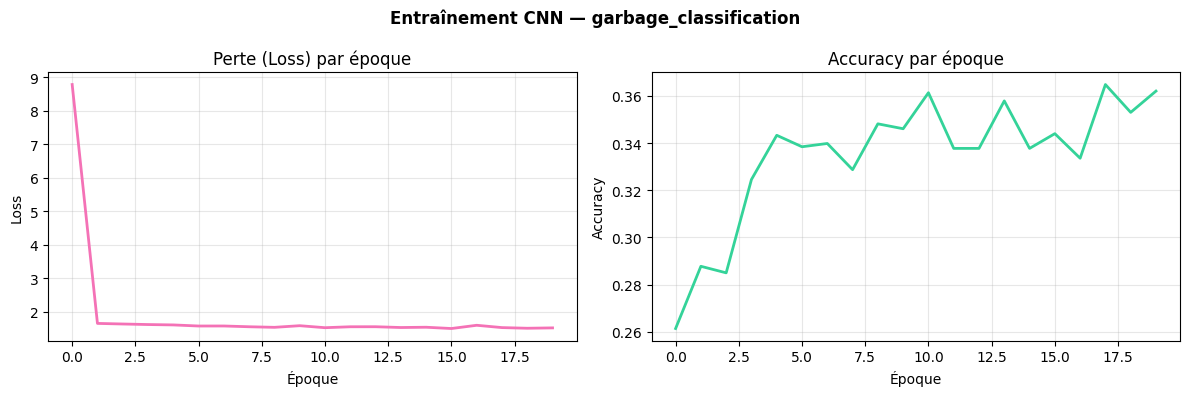


📊 RAPPORT DE PERFORMANCE — CNN Personnalisé — garbage_classification
   Accuracy  (exactitude) : 0.3667 (36.7%)
   Precision (précision)  : 0.3993
   Recall    (rappel)     : 0.3667
   F1-Score               : 0.3301

📋 Rapport détaillé par classe :
              precision    recall  f1-score   support

   cardboard       0.95      0.62      0.75        66
       glass       0.22      0.95      0.35        55
       metal       0.38      0.22      0.28        60
       paper       0.60      0.34      0.44        76
     plastic       0.00      0.00      0.00        75
       trash       0.00      0.00      0.00        28

    accuracy                           0.37       360
   macro avg       0.36      0.35      0.30       360
weighted avg       0.40      0.37      0.33       360



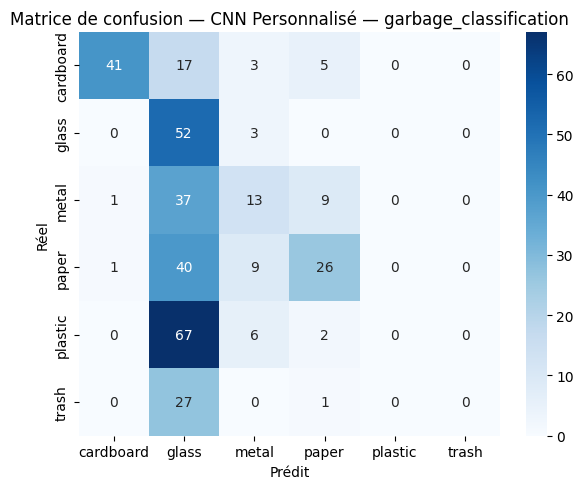


📁 Dataset : intel_image
   📊 Total images : 1998
   📚 Entraînement : 1599 | Test : 399
   🏷️  Classes (6) : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

🚀 Entraînement du CNN sur 'intel_image'...
   Époque [1/20] — Perte: 8.5760 — Accuracy: 0.2889
   Époque [5/20] — Perte: 1.3835 — Accuracy: 0.3784
   Époque [10/20] — Perte: 1.2649 — Accuracy: 0.4540
   Époque [15/20] — Perte: 1.2455 — Accuracy: 0.4828
   Époque [20/20] — Perte: 1.2722 — Accuracy: 0.4628


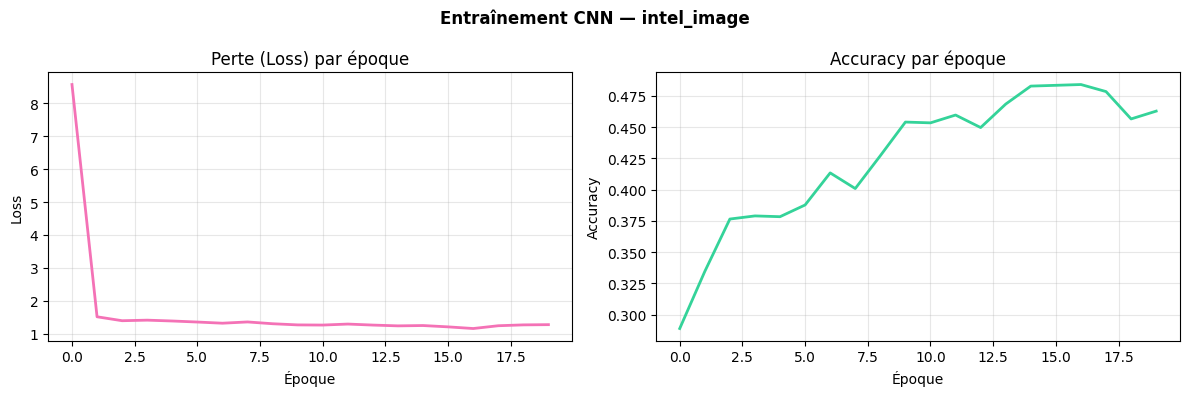


📊 RAPPORT DE PERFORMANCE — CNN Personnalisé — intel_image
   Accuracy  (exactitude) : 0.5338 (53.4%)
   Precision (précision)  : 0.5318
   Recall    (rappel)     : 0.5338
   F1-Score               : 0.5006

📋 Rapport détaillé par classe :
              precision    recall  f1-score   support

   buildings       0.47      0.66      0.55        58
      forest       1.00      0.78      0.88        69
     glacier       0.31      0.82      0.45        62
    mountain       0.62      0.32      0.42        82
         sea       0.00      0.00      0.00        66
      street       0.73      0.71      0.72        62

    accuracy                           0.53       399
   macro avg       0.52      0.55      0.50       399
weighted avg       0.53      0.53      0.50       399



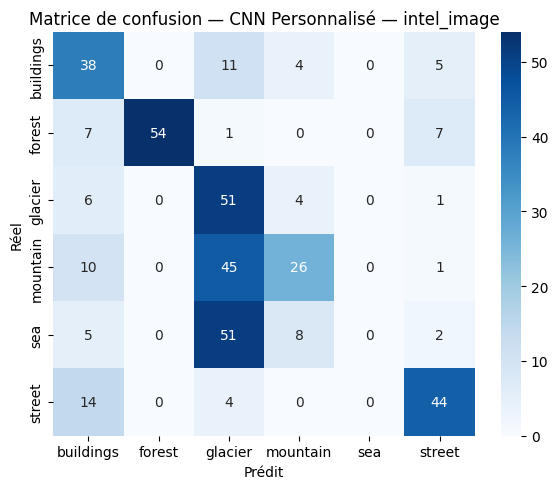


📁 Dataset : lung_colon_cancer
   📊 Total images : 2000
   📚 Entraînement : 1600 | Test : 400
   🏷️  Classes (5) : ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']

🚀 Entraînement du CNN sur 'lung_colon_cancer'...
   Époque [1/20] — Perte: 7.4415 — Accuracy: 0.5269
   Époque [5/20] — Perte: 0.7247 — Accuracy: 0.6844
   Époque [10/20] — Perte: 0.6041 — Accuracy: 0.7419
   Époque [15/20] — Perte: 0.5895 — Accuracy: 0.7656
   Époque [20/20] — Perte: 0.4929 — Accuracy: 0.8037


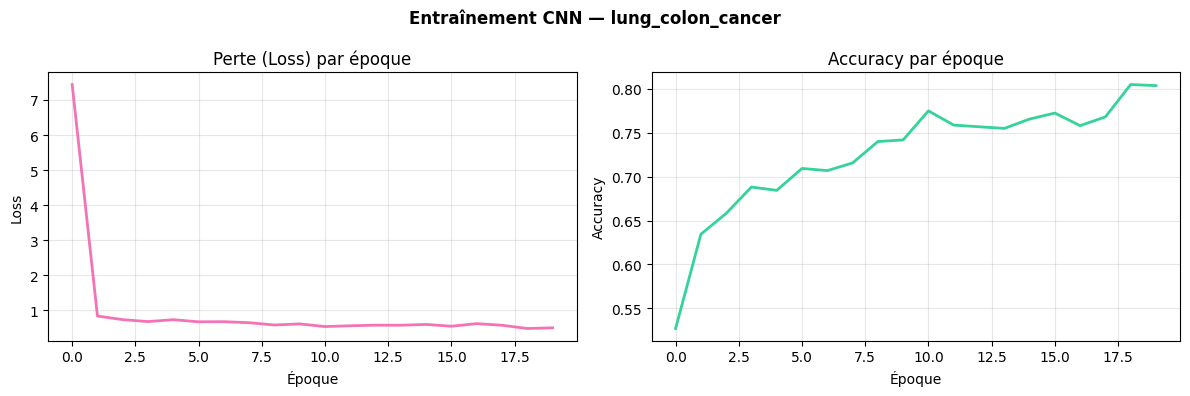


📊 RAPPORT DE PERFORMANCE — CNN Personnalisé — lung_colon_cancer
   Accuracy  (exactitude) : 0.8325 (83.2%)
   Precision (précision)  : 0.8364
   Recall    (rappel)     : 0.8325
   F1-Score               : 0.8326

📋 Rapport détaillé par classe :
              precision    recall  f1-score   support

   colon_aca       0.76      0.70      0.73        77
     colon_n       0.83      0.79      0.81        92
    lung_aca       0.74      0.89      0.80        79
      lung_n       0.98      0.95      0.96        83
    lung_scc       0.88      0.83      0.85        69

    accuracy                           0.83       400
   macro avg       0.84      0.83      0.83       400
weighted avg       0.84      0.83      0.83       400



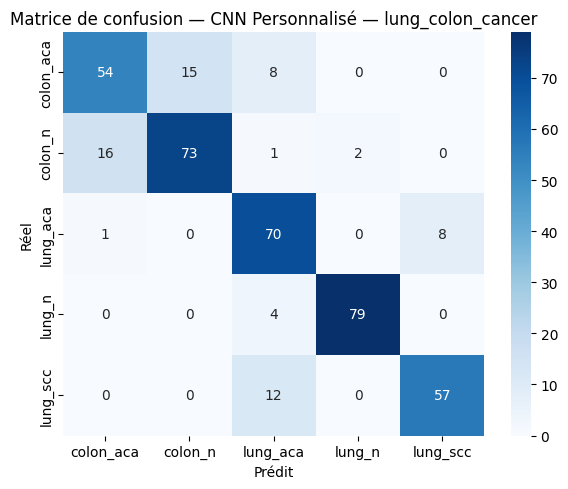


📁 Dataset : wildfire
   📊 Total images : 2433
   📚 Entraînement : 1947 | Test : 486
   🏷️  Classes (2) : ['fire', 'nofire']

🚀 Entraînement du CNN sur 'wildfire'...
   Époque [1/20] — Perte: 3.2407 — Accuracy: 0.6353
   Époque [5/20] — Perte: 0.5069 — Accuracy: 0.7324
   Époque [10/20] — Perte: 0.4853 — Accuracy: 0.7673
   Époque [15/20] — Perte: 0.4835 — Accuracy: 0.7565
   Époque [20/20] — Perte: 0.4595 — Accuracy: 0.7750


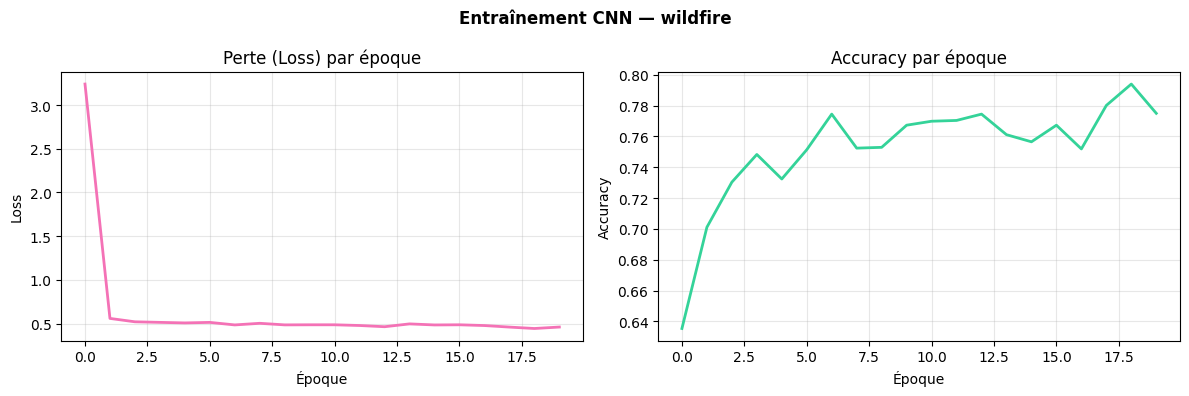


📊 RAPPORT DE PERFORMANCE — CNN Personnalisé — wildfire
   Accuracy  (exactitude) : 0.8066 (80.7%)
   Precision (précision)  : 0.8080
   Recall    (rappel)     : 0.8066
   F1-Score               : 0.8070

📋 Rapport détaillé par classe :
              precision    recall  f1-score   support

        fire       0.77      0.80      0.79       215
      nofire       0.84      0.81      0.82       271

    accuracy                           0.81       486
   macro avg       0.80      0.81      0.80       486
weighted avg       0.81      0.81      0.81       486



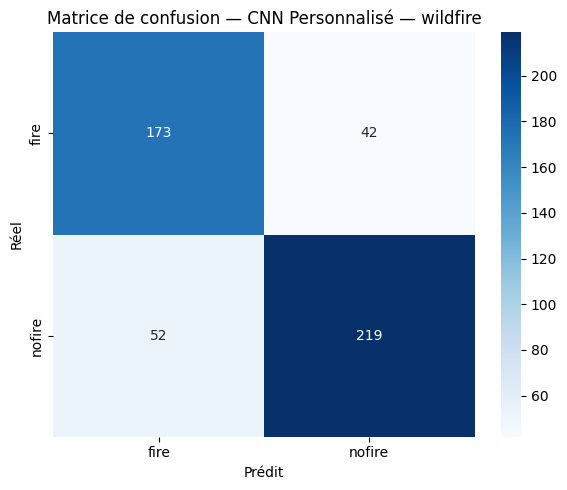

In [7]:
# ============================================================
# EXÉCUTION PARTIE 1 : ENTRAÎNER LE CNN SUR CHAQUE DATASET
# ============================================================
print("🔍 Recherche des datasets...")
liste_datasets = decouvrir_datasets(CHEMIN_DONNEES)

resultats_partie1 = {}
for nom_ds, chemin_ds in liste_datasets:
    print(f"\n{'='*60}")
    print(f"📁 Dataset : {nom_ds}")
    print(f"{'='*60}")
    train_loader, test_loader, classes, _ = charger_dataset(chemin_ds)
    y_vrai, y_pred, modele = entrainer_cnn(train_loader, test_loader, len(classes), nom_ds)
    metriques = rapport_performance(y_vrai, y_pred, classes, f"CNN Personnalisé — {nom_ds}")
    resultats_partie1[nom_ds] = metriques

---
#  PARTIE 2 — Extraction de caractéristiques + Classifieurs ML

**Principe du Transfer Learning :**
1. Charger un modèle pré-entraîné (ex: ResNet sur ImageNet)
2. Retirer la dernière couche (classification)
3. Utiliser le reste comme **extracteur de features**
4. Entraîner un classifieur ML classique sur ces features

**Architectures testées :** LeNet-5, AlexNet, VGGNet, ResNet, GoogLeNet, MobileNet  
**Classifieurs testés :** Decision Tree, AdaBoost, XGBoost, LightGBM, KNN


In [8]:
# ============================================================
# DÉFINITION DES EXTRACTEURS DE CARACTÉRISTIQUES
# ============================================================

def creer_extracteur(nom_architecture):
    """
    Crée un extracteur de features à partir d'une architecture pré-entraînée.
    On retire la dernière couche FC (classification) et on garde le reste.
    
    Paramètres:
        nom_architecture (str): Nom de l'architecture
        
    Retourne:
        modele (nn.Module): Modèle sans la dernière couche
        taille_features (int): Dimension du vecteur de features en sortie
    """
    if nom_architecture == "LeNet-5":
        # LeNet-5 simplifié (pas de modèle pré-entraîné officiel)
        modele = nn.Sequential(
            nn.Conv2d(3, 6, 5), nn.ReLU(), nn.AvgPool2d(2),
            nn.Conv2d(6, 16, 5), nn.ReLU(), nn.AvgPool2d(2),
            nn.Flatten(),
            nn.Linear(16 * 53 * 53, 120), nn.ReLU(),
            nn.Linear(120, 84), nn.ReLU()
        )
        return modele, 84
    
    elif nom_architecture == "AlexNet":
        modele = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        taille = modele.classifier[6].in_features  # 4096
        modele.classifier[6] = nn.Identity()  # Retirer la dernière couche
        return modele, taille
    
    elif nom_architecture == "VGGNet":
        modele = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        taille = modele.classifier[6].in_features  # 4096
        modele.classifier[6] = nn.Identity()
        return modele, taille
    
    elif nom_architecture == "ResNet":
        modele = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        taille = modele.fc.in_features  # 2048
        modele.fc = nn.Identity()
        return modele, taille
    
    elif nom_architecture == "GoogLeNet":
        modele = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)
        taille = modele.fc.in_features  # 1024
        modele.fc = nn.Identity()
        return modele, taille
    
    elif nom_architecture == "MobileNet":
        modele = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        taille = modele.classifier[1].in_features  # 1280
        modele.classifier = nn.Identity()
        return modele, taille
    
    else:
        raise ValueError(f"Architecture inconnue : {nom_architecture}")


def extraire_features(modele, data_loader):
    """
    Extrait les features de toutes les images d'un DataLoader
    en passant les images dans le modèle (sans la dernière couche).
    
    Retourne:
        features (np.array): Matrice (nb_images, taille_features)
        labels (np.array): Vecteur des labels
    """
    modele.eval()
    modele.to(DEVICE)
    
    toutes_features = []
    tous_labels = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(DEVICE)
            features = modele(images)
            
            # Si la sortie est un tuple (GoogLeNet en mode train), prendre le premier
            if isinstance(features, tuple):
                features = features[0]
            
            # Aplatir si nécessaire
            features = features.view(features.size(0), -1)
            
            toutes_features.append(features.cpu().numpy())
            tous_labels.append(labels.numpy())
    
    return np.vstack(toutes_features), np.concatenate(tous_labels)


# Liste des architectures à tester
ARCHITECTURES = ["AlexNet", "VGGNet", "ResNet", "GoogLeNet", "MobileNet"]
# Note : LeNet-5 est exclu par défaut car il n'a pas de poids pré-entraînés.
# Décommenter la ligne suivante pour l'inclure (performances moindres) :
# ARCHITECTURES = ["LeNet-5", "AlexNet", "VGGNet", "ResNet", "GoogLeNet", "MobileNet"]

# Liste des classifieurs ML à tester
CLASSIFIEURS = {
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "AdaBoost": AdaBoostClassifier(random_state=SEED, algorithm='SAMME'),
    "XGBoost": xgb.XGBClassifier(random_state=SEED, verbosity=1),
    "LightGBM": lgb.LGBMClassifier(random_state=SEED, verbose=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

print(f"✅ {len(ARCHITECTURES)} architectures et {len(CLASSIFIEURS)} classifieurs configurés")


✅ 5 architectures et 5 classifieurs configurés


In [9]:
# ============================================================
# EXÉCUTION PARTIE 2 : EXTRACTION + CLASSIFICATION
# ============================================================
resultats_partie2 = []

for nom_ds, chemin_ds in liste_datasets:
    print(f"\n{'#'*70}")
    print(f"# 📁 DATASET : {nom_ds}")
    print(f"{'#'*70}")
    
    # Charger les données
    train_loader, test_loader, classes, _ = charger_dataset(chemin_ds)
    
    for nom_arch in ARCHITECTURES:
        print(f"\n🏗️  Architecture : {nom_arch}")
        print("-" * 50)
        
        try:
            # Créer l'extracteur
            extracteur, taille_feat = creer_extracteur(nom_arch)
            print(f"   Taille du vecteur de features : {taille_feat}")
            
            # Extraire les features
            print("   ⏳ Extraction des features (train)...")
            X_train, y_train = extraire_features(extracteur, train_loader)
            print("   ⏳ Extraction des features (test)...")
            X_test, y_test = extraire_features(extracteur, test_loader)
            print(f"   ✅ Features extraites : train={X_train.shape}, test={X_test.shape}")
            
            # Normaliser les features
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
            
            # Tester chaque classifieur
            for nom_clf, clf in CLASSIFIEURS.items():
                print(f"\n   🔄 {nom_clf}...", end=" ")
                
                # Entraîner
                clf.fit(X_train, y_train)
                
                # Prédire
                y_pred = clf.predict(X_test)
                
                # Métriques
                acc = accuracy_score(y_test, y_pred)
                prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
                rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
                f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
                
                print(f"Acc={acc:.4f} | F1={f1:.4f}")
                
                resultats_partie2.append({
                    'Dataset': nom_ds,
                    'Architecture': nom_arch,
                    'Classifieur': nom_clf,
                    'Accuracy': acc,
                    'Precision': prec,
                    'Recall': rec,
                    'F1-Score': f1
                })
        
        except Exception as e:
            print(f"   ⚠️ Erreur avec {nom_arch}: {e}")

# ---- TABLEAU COMPARATIF ----
if resultats_partie2:
    df_res2 = pd.DataFrame(resultats_partie2)
    print("\n\n" + "="*70)
    print("📊 TABLEAU COMPARATIF — PARTIE 2")
    print("="*70)
    print(df_res2.to_string(index=False))
    
    # Meilleure combinaison
    meilleur = df_res2.loc[df_res2['F1-Score'].idxmax()]
    print(f"\n🏆 MEILLEURE COMBINAISON :")
    print(f"   Architecture: {meilleur['Architecture']}")
    print(f"   Classifieur:  {meilleur['Classifieur']}")
    print(f"   F1-Score:     {meilleur['F1-Score']:.4f}")



######################################################################
# 📁 DATASET : garbage_classification
######################################################################
   📊 Total images : 1802
   📚 Entraînement : 1442 | Test : 360
   🏷️  Classes (6) : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

🏗️  Architecture : AlexNet
--------------------------------------------------
   Taille du vecteur de features : 4096
   ⏳ Extraction des features (train)...
   ⏳ Extraction des features (test)...
   ✅ Features extraites : train=(1442, 4096), test=(360, 4096)

   🔄 Decision Tree... Acc=0.4889 | F1=0.4910

   🔄 AdaBoost... Acc=0.5333 | F1=0.5377

   🔄 XGBoost... Acc=0.7472 | F1=0.7452

   🔄 LightGBM... Acc=0.7667 | F1=0.7626

   🔄 KNN... Acc=0.6278 | F1=0.6194

🏗️  Architecture : VGGNet
--------------------------------------------------
   Taille du vecteur de features : 4096
   ⏳ Extraction des features (train)...
   ⏳ Extraction des features (test)...
   ✅ Features